<a href="https://colab.research.google.com/github/AleksanderTep/diploma/blob/main/diploma_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Устанавливаем конкретные совместимые версии (без конфликтов)
!pip install -U numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.2 nltk==3.9.1 matplotlib==3.9.4 seaborn==0.13.2
# Устанавливаем совместимый PyTorch (CUDA 12.4)
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124
# Устанавливаем transformers и сопутствующие
!pip install transformers==4.44.2 tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 103.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━ 357.5/908.2 MB 208.0 MB/s eta 0:00:03

In [ ]:
# Проверка установки
import sys
import torch
import transformers
import sklearn
import pandas as pd
import nltk

print("="*50)
print("ВЕРСИИ БИБЛИОТЕК:")
print(f"Python: {sys.version}")
print(f"torch: {torch.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas: {pd.__version__}")
print(f"nltk: {nltk.__version__}")

print(f" GPU доступен: {torch.cuda.get_device_name(0)}")
print(f" CUDA версия: {torch.version.cuda}")

ВЕРСИИ БИБЛИОТЕК:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.10.0+cu128
transformers: 5.0.0
scikit-learn: 1.6.1
pandas: 2.2.2
nltk: 3.9.1
 GPU доступен: Tesla T4
 CUDA версия: 12.8


In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

# Путь к исходному файлу
FILE_PATH = "/content/drive/MyDrive/датасет/rusentiment_preselected_posts.csv"

df = pd.read_csv(FILE_PATH)
print(f"Количество загруженных строк: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
print("\nПервые 3 строки:")
print(df.head(3))
print("\nРаспределение по меткам (до фильтрации):")
print(df['label'].value_counts())

Mounted at /content/drive
Количество загруженных строк: 6950
Колонки: ['label', 'text']

Первые 3 строки:
      label                                               text
0   neutral           Прорвём информационную блокаду изнутри. 
1  negative  Никогда у меня не будет "одного приложения для...
2      skip  Кури-и тебя не укусит злая собака, потому что ...

Распределение по меткам (до фильтрации):
label
neutral     2977
positive    1475
negative    1360
skip         904
speech       234
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Оставляем только positive и negative
df_binary = df[df['label'].isin(['positive', 'negative'])].copy()

# Преобразуем метки: positive -> 1, negative -> 0
df_binary['label'] = df_binary['label'].map({'positive': 1, 'negative': 0})

print(f"После фильтрации строк: {len(df_binary)}")
print(f"Распределение классов:\n{df_binary['label'].value_counts()}")

# Сохраняем бэкап на Google Диск
df_binary.to_csv('/content/drive/MyDrive/df_binary_backup.csv', index=False)
print("Бэкап сохранён: /content/drive/MyDrive/df_binary_backup.csv")

print("\nПримеры:")
print(df_binary[['label', 'text']].head(4))

NameError: name 'df' is not defined

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

nltk.download('stopwords')

# Стоп-слова без 'не' и 'ни'
stop_words = set(stopwords.words('russian'))
stop_words = stop_words - {'не', 'ни'}

# Дополнительные стоп-слова (по желанию)
extra_stop_words = {'это', 'так', 'вот', 'быть', 'весь', 'который', 'еще', 'уже', 'сказать'}
stop_words.update(extra_stop_words)

# Стеммер для русского
stemmer = SnowballStemmer("russian")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    # Сохраняем ! ? ' - а также : ( ) для смайликов
    text = re.sub(r'[^a-zа-яё0-9\s:\(\)\!\?\'\-]', '', text)
    return text

def stem_text(text):
    words = text.split()
    stems = []
    for word in words:
        # Сохраняем короткие слова (включая 'не', 'ни')
        if len(word) <= 2:
            stems.append(word)
            continue
        # Сохраняем смайлики
        if word in [':)', ':(' , ':)', ':d', ':D', ':\')', ':\\(', ':\'(', ':\\)']:
            stems.append(word)
            continue
        # Стемминг
        stemmed = stemmer.stem(word)
        if stemmed not in stop_words:
            stems.append(stemmed)
    return ' '.join(stems)

print("Начало предобработки...")
df_binary['clean_text'] = df_binary['text'].apply(clean_text)
print("Очистка завершена. Стемминг...")
df_binary['lemma_text'] = df_binary['clean_text'].apply(stem_text)
print("Стемминг завершён.")

# Сохраняем обновлённый df_binary (с lemma_text)
df_binary.to_csv('/content/drive/MyDrive/df_binary_backup.csv', index=False)
print("Бэкап обновлён (с lemma_text).")

print("\nПримеры после предобработки:")
for i in range(5):
    print(f"Оригинал: {df_binary['text'].iloc[i][:80]}...")
    print(f"Стеммы: {df_binary['lemma_text'].iloc[i][:80]}...")
    print("-" * 50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Начало предобработки...
Очистка завершена. Стемминг...
Стемминг завершён.
Бэкап обновлён (с lemma_text).

Примеры после предобработки:
Оригинал: Никогда у меня не будет "одного приложения для всего". В топку эти ущербные унив...
Стеммы: никогд у мен не одн приложен всег в топк эт ущербн универсальн...
--------------------------------------------------
Оригинал: Просто в дрожь бросает. Как можно быть такими тупыми? 
От хохлянских фразочек я ...
Стеммы: прост в дрож броса можн быт тупыми? от хохлянск фразочек я офигева а от школярск...
--------------------------------------------------
Оригинал: косяк, я соскучилась по тебе (...
Стеммы: косяк я соскуч по теб (...
--------------------------------------------------
Оригинал: Плсторел :'(...
Стеммы: плсторел :'(...
--------------------------------------------------
Оригинал: бляять да забей ты ужеееееее!!!!!...
Стеммы: бляя да заб ты ужеееееее!!!!!...
--------------------------------------------------


Train: 2268, Test: 567
Распределение классов в train:
{0: 1088, 1: 1180}
Распределение классов в test:
{0: 272, 1: 295}
Размер матрицы TF-IDF (train): (2268, 5000)

TF‑IDF + Logistic Regression
              precision    recall  f1-score   support

 Негатив (0)       0.74      0.73      0.74       272
 Позитив (1)       0.76      0.77      0.76       295

    accuracy                           0.75       567
   macro avg       0.75      0.75      0.75       567
weighted avg       0.75      0.75      0.75       567

F1 macro: 0.7490


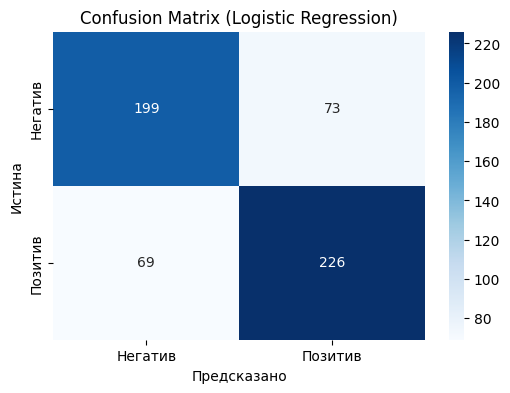


 Модель LogReg и векторайзер сохранены на диск.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Используем предобработанный df_binary (предыдущая)
# Если df_binary не в памяти, загрузим из бэкапа
try:
    df_binary
except NameError:
    df_binary = pd.read_csv('/content/drive/MyDrive/df_binary_backup.csv')
    print("Загружен df_binary из бэкапа")

# Проверяем наличие колонки lemma_text
if 'lemma_text' not in df_binary.columns:
    raise ValueError("Колонка lemma_text не найдена. Сначала выполните ячейку 4 (стемминг).")

X = df_binary['lemma_text']
y = df_binary['label']

# Разделение 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Распределение классов в train:\n{y_train.value_counts().sort_index().to_dict()}")
print(f"Распределение классов в test:\n{y_test.value_counts().sort_index().to_dict()}")

# TF-IDF с биграммами                                                                                          #################
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"Размер матрицы TF-IDF (train): {X_train_tfidf.shape}")

# Логистическая регрессия
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

# Метрики
print("\n" + "="*50)
print("TF‑IDF + Logistic Regression")
print("="*50)
print(classification_report(y_test, y_pred_lr, target_names=['Негатив (0)', 'Позитив (1)']))
print(f"F1 macro: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Негатив', 'Позитив'],
            yticklabels=['Негатив', 'Позитив'])
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.show()

# Сохраняем модели и векторайзер для последующего использования
import joblib
joblib.dump(lr, '/content/drive/MyDrive/lr_model.pkl')
joblib.dump(tfidf, '/content/drive/MyDrive/tfidf_vectorizer.pkl')
print("\n Модель LogReg и векторайзер сохранены на диск.")

In [ ]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Загружаем df_binary (если не в памяти)
try:
    df_binary
except NameError:
    df_binary = pd.read_csv('/content/drive/MyDrive/df_binary_backup.csv')
    print("Загружен df_binary из бэкапа")

# Проверка наличия колонки lemma_text
if 'lemma_text' not in df_binary.columns:
    raise ValueError("Колонка lemma_text не найдена. Сначала выполните ячейку 4 (стемминг).")

X = df_binary['lemma_text']
y = df_binary['label']

# Разделение (те же параметры, что в ячейке 5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# Модель и токенизатор                                                                     ############################
model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

# Токенизация
train_texts = X_train.tolist()
test_texts = X_test.tolist()

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")

# Датасеты
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train.tolist())
test_dataset = SentimentDataset(test_encodings, y_test.tolist())

# Метрики
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# Аргументы обучения
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Начало обучения RuBERT‑tiny2 (2 эпохи)...")
trainer.train()

print("\nОценка на тестовой выборке:")
eval_results = trainer.evaluate()
print(eval_results)

# Детальный отчёт
from sklearn.metrics import classification_report
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(-1)
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Негатив (0)', 'Позитив (1)']))

save_path = '/content/drive/MyDrive/rubert_tiny2_sentiment'
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"\n Модель сохранена: {save_path}")

Train: 2268, Test: 567
Используется устройство: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.


Оценка на тестовой выборке:


{'eval_loss': 0.429847776889801, 'eval_accuracy': 0.8165784832451499, 'eval_f1': 0.8129496402877698, 'eval_precision': 0.8659003831417624, 'eval_recall': 0.7661016949152543, 'eval_runtime': 0.5613, 'eval_samples_per_second': 1010.192, 'eval_steps_per_second': 64.139, 'epoch': 2.0}

Classification Report:
              precision    recall  f1-score   support

 Негатив (0)       0.77      0.87      0.82       272
 Позитив (1)       0.87      0.77      0.81       295

    accuracy                           0.82       567
   macro avg       0.82      0.82      0.82       567
weighted avg       0.82      0.82      0.82       567



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Модель сохранена: /content/drive/MyDrive/rubert_tiny2_sentiment


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК
                 F1 (негатив)  F1 (позитив)  F1 macro  Accuracy
TF‑IDF + LogReg        0.7370        0.7609    0.7490    0.7496
RuBERT‑tiny2           0.8201        0.8129    0.8165    0.8166


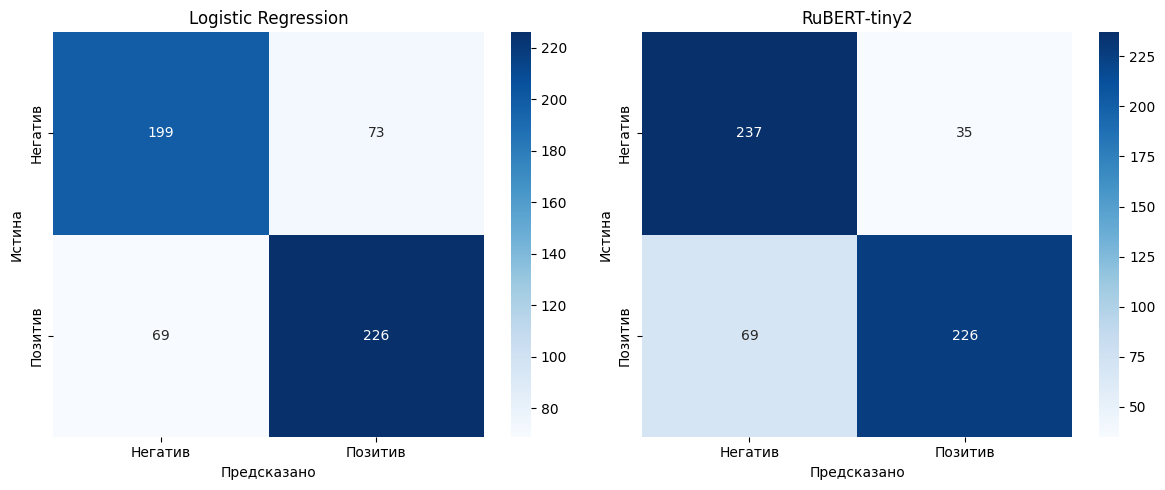


ПРИМЕРЫ ПРЕДСКАЗАНИЙ (20 тестовых отзывов):
                                                                                                                                                                                                                                             text true_label pred_lr pred_ru
                                                                                                                                                                                                                                 очен громк плака    Негатив Негатив Негатив
я помн перв заявк в друзья) перв сообщение) перв звонок на телефон) перв встречу) перв ден когд гуля вместе) перв поцелуй) перв ноч когд вмест спали) перв подарок) перв когд познаком наш родители) я помн кажд наш день) любл теб очен сильно))    Позитив Позитив Позитив
                                                                                                                                                    

In [ ]:
import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Загружаем данные и предобработанные тексты
df_binary = pd.read_csv('/content/drive/MyDrive/df_binary_backup.csv')
X = df_binary['lemma_text']
y = df_binary['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Загружаем обученную логистическую регрессию и векторайзер
lr = joblib.load('/content/drive/MyDrive/lr_model.pkl')
tfidf = joblib.load('/content/drive/MyDrive/tfidf_vectorizer.pkl')
X_test_tfidf = tfidf.transform(X_test)
y_pred_lr = lr.predict(X_test_tfidf)

# 3. Загружаем сохранённую RuBERT‑tiny2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "/content/drive/MyDrive/rubert_tiny2_sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

# Токенизация тестовых текстов
test_texts = X_test.tolist()
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
all_preds = []
batch_size = 16
for i in range(0, len(test_texts), batch_size):
    batch = {k: v[i:i+batch_size].to(device) for k, v in test_encodings.items()}
    with torch.no_grad():
        outputs = model(**batch)
    preds = outputs.logits.argmax(-1).cpu().numpy()
    all_preds.extend(preds)
y_pred_ru = np.array(all_preds)

# 4. Сравнительная таблица метрик
def get_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, target_names=['Негатив', 'Позитив'])
    return {
        'F1 (негатив)': report['Негатив']['f1-score'],
        'F1 (позитив)': report['Позитив']['f1-score'],
        'F1 macro': report['macro avg']['f1-score'],
        'Accuracy': report['accuracy']
    }

metrics_lr = get_metrics(y_test, y_pred_lr)
metrics_ru = get_metrics(y_test, y_pred_ru)
comparison = pd.DataFrame([metrics_lr, metrics_ru], index=['TF‑IDF + LogReg', 'RuBERT‑tiny2'])
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК")
print(comparison.round(4))

# 5. Матрицы ошибок рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(axes, [y_pred_lr, y_pred_ru], ['Logistic Regression', 'RuBERT‑tiny2']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Негатив', 'Позитив'], yticklabels=['Негатив', 'Позитив'])
    ax.set_title(title)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истина')
plt.tight_layout()
plt.show()

# 6. Примеры предсказаний (20 первых)
sample_df = pd.DataFrame({
    'text': X_test.values[:20],
    'true_label': y_test.values[:20],
    'pred_lr': y_pred_lr[:20],
    'pred_ru': y_pred_ru[:20]
})
sample_df['true_label'] = sample_df['true_label'].map({0: 'Негатив', 1: 'Позитив'})
sample_df['pred_lr'] = sample_df['pred_lr'].map({0: 'Негатив', 1: 'Позитив'})
sample_df['pred_ru'] = sample_df['pred_ru'].map({0: 'Негатив', 1: 'Позитив'})
print("\nПРИМЕРЫ ПРЕДСКАЗАНИЙ (20 тестовых отзывов):")
print(sample_df.to_string(index=False))

# 7. Анализ ошибок: где RuBERT ошибся, а LogReg прав
errors = pd.DataFrame({
    'text': X_test.values,
    'true': y_test.values,
    'lr_pred': y_pred_lr,
    'ru_pred': y_pred_ru
})
errors['true_label'] = errors['true'].map({0: 'Негатив', 1: 'Позитив'})
errors['lr_correct'] = errors['true'] == errors['lr_pred']
errors['ru_correct'] = errors['true'] == errors['ru_pred']

only_lr_correct = errors[(~errors['ru_correct']) & errors['lr_correct']]
print(f"\n Примеры, где RuBERT ошибся, а LogReg был прав ({len(only_lr_correct)}):")
if len(only_lr_correct) > 0:
    print(only_lr_correct[['text', 'true_label', 'lr_pred', 'ru_pred']].head(5).to_string(index=False))

both_wrong = errors[(~errors['ru_correct']) & (~errors['lr_correct'])]
print(f"\n Примеры, где ошиблись обе модели ({len(both_wrong)}):")
if len(both_wrong) > 0:
    print(both_wrong[['text', 'true_label', 'lr_pred', 'ru_pred']].head(3).to_string(index=False))

Таблица количественной сводки ошибок (W, X, Y, Z)
                    Ситуация  Количество примеров
Обе модели дали верный ответ                  365
 LogReg верна, RuBERT ошибся                   60
 RuBERT верна, LogReg ошибся                   98
         Обе модели ошиблись                   44
                       Всего                  567


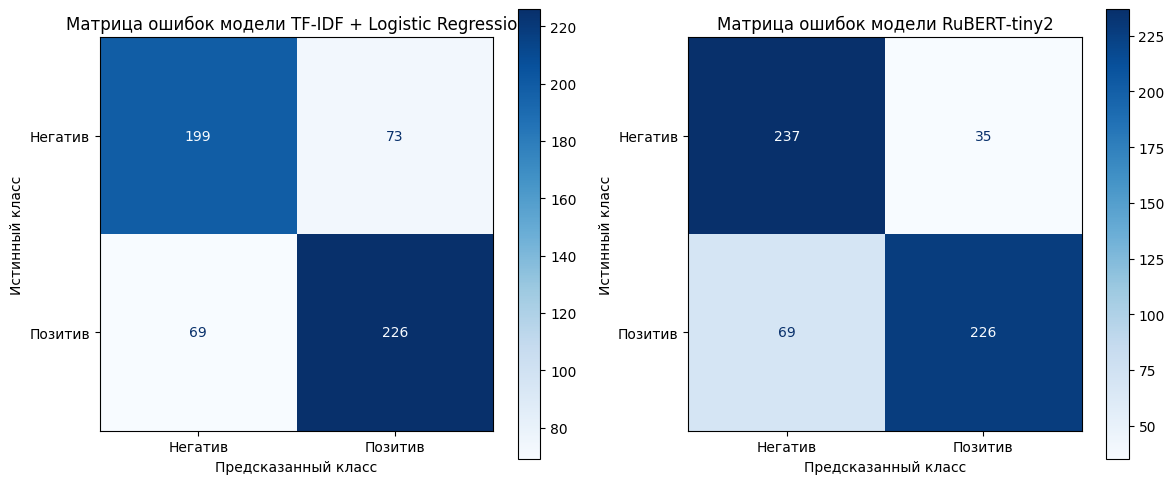


Примечание:
LogReg: правильно 425 из 567 отзывов
RuBERT: правильно 463 из 567 отзывов


In [ ]:
# ТАБЛИЦА И МАТРИЦЫ ОШИБОК
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Подсчёт WXYZ
both_correct = sum((y_test == y_pred_lr) & (y_test == y_pred_ru))
lr_correct_ru_wrong = sum((y_test == y_pred_lr) & (y_test != y_pred_ru))
lr_wrong_ru_correct = sum((y_test != y_pred_lr) & (y_test == y_pred_ru))
both_wrong = sum((y_test != y_pred_lr) & (y_test != y_pred_ru))
total = len(y_test)

# 2. Таблица WXYZ
error_summary = pd.DataFrame({
    "Ситуация": [
        "Обе модели дали верный ответ",
        "LogReg верна, RuBERT ошибся",
        "RuBERT верна, LogReg ошибся",
        "Обе модели ошиблись",
        "Всего"
    ],
    "Количество примеров": [
        both_correct,
        lr_correct_ru_wrong,
        lr_wrong_ru_correct,
        both_wrong,
        total
    ]
})

print("Таблица количественной сводки ошибок (W, X, Y, Z)")
print(error_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Негатив', 'Позитив'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title("Матрица ошибок модели TF‑IDF + Logistic Regression")
axes[0].set_xlabel("Предсказанный класс")
axes[0].set_ylabel("Истинный класс")

cm_ru = confusion_matrix(y_test, y_pred_ru)
disp_ru = ConfusionMatrixDisplay(confusion_matrix=cm_ru, display_labels=['Негатив', 'Позитив'])
disp_ru.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title("Матрица ошибок модели RuBERT‑tiny2")
axes[1].set_xlabel("Предсказанный класс")
axes[1].set_ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# 5. Краткая справка
print(f"\nПримечание:")
print(f"LogReg: правильно {cm_lr[0][0] + cm_lr[1][1]} из {total} отзывов")
print(f"RuBERT: правильно {cm_ru[0][0] + cm_ru[1][1]} из {total} отзывов")

--------------------------------------------------------------------------------------

In [ ]:
# техническая проверка
import pandas as pd
import numpy as np
import torch
import joblib
import re
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

# 1. Подключение диска
drive.mount('/content/drive')

# 2. Загрузка моделей
lr = joblib.load('/content/drive/MyDrive/lr_model.pkl')
tfidf = joblib.load('/content/drive/MyDrive/tfidf_vectorizer.pkl')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/rubert_tiny2_sentiment')
rubert_model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/rubert_tiny2_sentiment')
rubert_model.to(device)
rubert_model.eval()

# 3. Парсер CSV (последняя запятая)
def parse_reviews_csv(file_path):
    reviews = []
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        last_comma = line.rfind(',')
        if last_comma == -1:
            continue
        text = line[:last_comma].strip()
        label_str = line[last_comma + 1:].strip()
        try:
            label = int(label_str)
        except:
            continue
        reviews.append({"text": text, "label": label})
    return reviews

# 4. Загрузка отзывов с диска
file_path = '/content/drive/MyDrive/датасет/new_reviews.csv'
new_reviews = parse_reviews_csv(file_path)
print(f"Загружено отзывов: {len(new_reviews)}")

# 5. Предобработка
stop_words = set(stopwords.words('russian')) - {'не', 'ни'}
stemmer = SnowballStemmer("russian")

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^a-zа-яё0-9\s:\(\)\!\?\'\-]', '', text)
    return text

def stem_text(text):
    if not isinstance(text, str):
        text = str(text)
    words = text.split()
    stems = []
    for word in words:
        if len(word) <= 2:
            stems.append(word)
            continue
        if word in [':)', ':(' , ':)', ':d', ':D', ':\')', ':\\(', ':\'(', ':\\)']:
            stems.append(word)
            continue
        stemmed = stemmer.stem(word)
        if stemmed not in stop_words:
            stems.append(stemmed)
    return ' '.join(stems)

# 6. Прогон моделей
THRESHOLD = 0.75
results = []

for rev in new_reviews:
    raw_text = rev["text"]
    true_label = rev["label"]

    # LogReg (только для сравнения, на решение не влияет)
    clean = clean_text(raw_text)
    stemmed = stem_text(clean)
    X_vec = tfidf.transform([stemmed])
    proba_lr = lr.predict_proba(X_vec)[0]
    confidence_lr = max(proba_lr)
    pred_lr_raw = lr.predict(X_vec)[0]
    pred_lr = "Позитив" if pred_lr_raw == 1 else "Негатив"

    # RuBERT (основная модель)
    clean_ru = clean_text(raw_text)
    inputs = tokenizer(clean_ru, return_tensors="pt", truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = rubert_model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    confidence_ru = max(probs)
    pred_ru_raw = np.argmax(probs)

    # Решение принимает RuBERT, если уверенность >= порога
    true_text = "Позитив" if true_label == 1 else "Негатив"
    if confidence_ru >= THRESHOLD:
        final_decision = "Позитив" if pred_ru_raw == 1 else "Негатив"
        comment = "Автоматически (RuBERT)"
        if final_decision == true_text:
            comment += " верно"
        else:
            comment += " ошибся"
    else:
        final_decision = "на проверку"
        comment = "Требуется ручная проверка (уверенность RuBERT < 0.75)"

    results.append({
        "Отзыв (сокращённо)": raw_text[:65] + "..." if len(raw_text) > 65 else raw_text,
        "Ручная оценка": true_text,
        "LogReg (справочно)": f"{pred_lr} ({confidence_lr:.2f})",
        "RuBERT уверенность": f"{confidence_ru:.2f}",
        "Решение системы": final_decision,
        "Комментарий": comment
    })

# 7. Таблица 2 – поотзывное сравнение
df_table2 = pd.DataFrame(results)
print("\nТаблица 2 – Результаты классификации новых отзывов (RuBERT решает, порог = 0.75)")
print(df_table2.to_string(index=False))

# 8. Таблица 3 – сводка точности (только автоматические решения)
auto_decisions = [r for r in results if "Автоматически" in r["Комментарий"] and "верно" in r["Комментарий"]]
total_auto = len([r for r in results if "Автоматически" in r["Комментарий"]])
correct_auto = len(auto_decisions)

auto_df = pd.DataFrame({
    "Модель": ["RuBERT‑tiny2 (порог 0.75)"],
    "Автоматически обработано": [f"{total_auto} из {len(results)}"],
    "Из них верно": [f"{correct_auto} из {total_auto}"],
    "Точность (на авто)": [f"{correct_auto/total_auto:.2f}" if total_auto > 0 else "—"]
})

print("\nТаблица 3 – Сводка работы системы (только автоматические решения)")
print(auto_df.to_string(index=False))

need_check = len([r for r in results if "на проверку" in r["Решение системы"]])
print(f"\nИтог: {need_check} отзывов отправлено на ручную проверку (уверенность RuBERT < 0.75).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружено отзывов: 8

Таблица 2 – Результаты классификации новых отзывов (RuBERT решает, порог = 0.75)
                                                  Отзыв (сокращённо) Ручная оценка LogReg (справочно) RuBERT уверенность Решение системы                   Комментарий
Через папу недель невыносимо стало пользоваться. Зависат, если кт...       Негатив     Негатив (0.59)               0.85         Негатив  Автоматически (RuBERT) верно
Недостатки: Камера не очень. нету оптического стабилизатора. Бата...       Негатив     Позитив (0.51)               0.87         Негатив  Автоматически (RuBERT) верно
                                    на второй день перестал работать       Негатив     Позитив (0.59)               0.80         Негатив  Автоматически (RuBERT) верно
Этот телефон хорош просто как звонилка, более ни для чего он не п...       Негатив     Негатив (0.63)               0.76         Позитив Автоматически (RuBERT) ошибся
Отличный телефон, все летает, правда его использует бабушка 80

In [ ]:
#краткий вывод
import pandas as pd


df_display = pd.DataFrame(results)
df_display["Отзыв (сокращённо)"] = df_display["Отзыв (сокращённо)"].apply(
    lambda x: x[:25] + "..." if len(x) > 25 else x
)

df_display["Комментарий"] = df_display["Комментарий"].replace(
    "Требуется ручная проверка (уверенность RuBERT < 0.7)",
    "        уверенность RuBERT < 0.7 "
)

# Переименовываем для краткости
df_display = df_display.rename(columns={
    "Отзыв (сокращённо)": "Отзыв (25 симв.)",
    "Ручная оценка": "Ручная",
    "LogReg (справочно)": "LogReg     ",
    "RuBERT уверенность": "RuBERT",
    "Решение системы": "Решение  ",
    "Комментарий": "Примечание       "
})

# Вывод основной таблицы
print("\nРезультаты классификации новых отзывов (RuBERT решает, порог = 0.7)")
print(df_display.to_string(index=False))

# Сводка
auto_data = {
    "Модель": ["RuBERT‑tiny2 (порог 0.7)"],
    "  Автоматически": [f"{total_auto} из {len(results)}"],
    "  Верно (авто)": [f"{correct_auto} из {total_auto}"],
    "  Точность (авто)": [f"{correct_auto/total_auto:.2f}" if total_auto > 0 else "—"]
}

df_auto = pd.DataFrame(auto_data)
print("\nСводка работы системы (только автоматические решения)")
print(df_auto.to_string(index=False))

print(f"\nНа ручную проверку отправлено: {need_check} отзывов")


Результаты классификации новых отзывов (RuBERT решает, порог = 0.7)
            Отзыв (25 симв.)  Ручная    LogReg      RuBERT Решение               Примечание       
Через папу недель невынос... Негатив Негатив (0.59)   0.85   Негатив  Автоматически (RuBERT) верно
Недостатки: Камера не оче... Негатив Позитив (0.51)   0.87   Негатив  Автоматически (RuBERT) верно
на второй день перестал р... Негатив Позитив (0.59)   0.80   Негатив  Автоматически (RuBERT) верно
Этот телефон хорош просто... Негатив Негатив (0.63)   0.76   Позитив Автоматически (RuBERT) ошибся
Отличный телефон, все лет... Позитив Позитив (0.72)   0.84   Позитив  Автоматически (RuBERT) верно
Внешний вид хороший, непл... Позитив Позитив (0.63)   0.86   Позитив  Автоматически (RuBERT) верно
ежедневно без передышки и... Позитив Негатив (0.64)   0.95   Позитив  Автоматически (RuBERT) верно
       Все чётко работает :) Позитив Позитив (0.59)   0.90   Позитив  Автоматически (RuBERT) верно

Сводка работы системы (только автоматич

--------------------------------------------------------------------------------------
#   
--------------------------------------------------------------------------------------

In [ ]:
# ЯЧЕЙКА А


import re
import torch
import joblib
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

nltk.download('stopwords', quiet=True)


print("Загрузка моделей...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = '/content/drive/MyDrive/rubert_tiny2_sentiment'
tokenizer = AutoTokenizer.from_pretrained(model_path)
rubert_model = AutoModelForSequenceClassification.from_pretrained(model_path)
rubert_model.to(device)
rubert_model.eval()


lr = joblib.load('/content/drive/MyDrive/lr_model.pkl')
tfidf = joblib.load('/content/drive/MyDrive/tfidf_vectorizer.pkl')


stop_words = set(stopwords.words('russian')) - {'не', 'ни'}
stemmer = SnowballStemmer("russian")

def clean_text(text):
    """Очистка для моделей (RuBERT и LogReg)"""
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^a-zа-яё0-9\s:\(\)\!\?\'\-]', '', text)
    return text

def stem_text(text):
    """Стемминг для LogReg """
    if not isinstance(text, str):
        text = str(text)
    words = text.split()
    stems = []
    for word in words:
        if len(word) <= 2:
            stems.append(word)
            continue
        if word in [':)', ':(' , ':)', ':d', ':D', ':\')', ':\\(', ':\'(', ':\\)']:
            stems.append(word)
            continue
        stemmed = stemmer.stem(word)
        if stemmed not in stop_words:
            stems.append(stemmed)
    return ' '.join(stems)

#  Универсальные категории с расширенными ключевыми словами
KEYWORDS = {
    'качество товара/услуги': [
        'качество', 'плохой', 'ужасный', 'сломался', 'не работает', 'дефект', 'брак',
        'неисправность', 'ошибка', 'проблема', 'некачественный', 'испорчен', 'поврежден',
        'не соответствует', 'зависает', 'завис', 'белый экран', 'перестал работать', 'камера',
        'батарея', 'динамик', 'пищит', 'шум', 'глючит', 'тормозит', 'заряд', 'разряжается',
        'неисправен', 'хрупкий', 'отвалился', 'битый', 'нерабочий', 'плохое качество'
    ],
    'доставка/сроки': [
        'доставка', 'курьер', 'почта', 'сдэк', 'боксберри', 'срок', 'опоздал', 'задержка',
        'долго', 'ждал', 'ожидание', 'привезли', 'не доставили', 'перенос', 'поздно',
        'месяц', 'неделя', 'дней', 'задерживается', 'вовремя', 'потеряли', 'повредили при доставке'
    ],
    'сервис/поддержка': [
        'поддержка', 'оператор', 'менеджер', 'сотрудник', 'обслуживание', 'сервис',
        'не отвечает', 'грубость', 'хамство', 'консультация', 'звонок', 'обратная связь',
        'не помогли', 'плохой сервис', 'некомпетентный', 'хам', 'грубиян'
    ],
    'цена/условия': [
        'цена', 'дорого', 'стоимость', 'переплата', 'скидка', 'тариф', 'условия',
        'комиссия', 'дешевле', 'завышена', 'оплата', 'деньги', 'не стоит', 'акция'
    ],
    'комплектация/соответствие': [
        'комплект', 'комплектация', 'отсутствует', 'не хватает', 'не положили', 'описание',
        'ожидал', 'ожидала', 'не соответствует', 'другой', 'вместо', 'размер', 'цвет',
        'характеристики', 'неполный', 'без кабеля', 'без инструкции'
    ],
    'общая жалоба/эмоциональный негатив': [
        'ужас', 'кошмар', 'плохо', 'отвратительно', 'разочарован', 'не нравится',
        'говно', 'хрень', 'больше не буду', 'не рекомендую', 'расстроен', 'не советую'
    ]
}

# Порядок выбора категории при нескольких совпадениях (по убыванию приоритета)
CATEGORY_PRIORITY = [
    'качество товара/услуги',
    'сервис/поддержка',
    'доставка/сроки',
    'комплектация/соответствие',
    'цена/условия',
    'общая жалоба/эмоциональный негатив',
    'прочее'
]

def categorize_negative(text):
    """
    Определяет категорию и тип негатива по исходному тексту (только lower).
    text: исходный отзыв (строка), приводится к нижнему регистру, но знаки препинания сохраняются.
    Возвращает: (категория, тип_негатива)
        тип_негатива: 'содержательный' если найдена конкретная категория
                      'несодержательный' если только 'общая жалоба' или 'прочее'
    """
    text_lower = text.lower()
    found = []
    for cat, keywords in KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                found.append(cat)
                break
    if not found:
        return 'прочее', 'несодержательный'
    # Выбираем категорию по приоритету
    for priority_cat in CATEGORY_PRIORITY:
        if priority_cat in found:
            category = priority_cat
            break
    else:
        category = found[0]
    # Тип негатива
    if category in ['общая жалоба/эмоциональный негатив', 'прочее']:
        neg_type = 'несодержательный'
    else:
        neg_type = 'содержательный'
    return category, neg_type

#  Определение приоритета и рекомендации ---
def assign_priority(category, sentiment, confidence, threshold=0.65):
    if confidence < threshold:
        return 'ручная проверка'
    if sentiment == 'positive':
        return None
    # Негативные с уверенностью >= порога
    if category in ['качество товара/услуги', 'доставка/сроки', 'сервис/поддержка', 'комплектация/соответствие']:
        return 'высокий'
    elif category in ['цена/условия', 'общая жалоба/эмоциональный негатив']:
        return 'средний'
    elif category == 'прочее':
        return 'средний'   # или 'низкий', но лучше средний
    else:
        return 'низкий'

def generate_recommendation(category, priority, sentiment, decision_status, confidence):
    """
    Генерирует текст рекомендации.
    Приоритет: решение на основе decision_status (manual перекрывает всё).
    """
    if decision_status == 'manual':
        return "Требуется ручная проверка: модель не уверена в тональности или отзыв содержит смешанную оценку."
    if sentiment == 'positive':
        return "Отзыв положительный, дополнительных действий не требуется."
    # Негативные с авто-решением
    if category == 'качество товара/услуги':
        return "Срочно передать в отдел качества/продуктовый отдел. Связаться с клиентом."
    elif category == 'доставка/сроки':
        return "Срочно передать в службу доставки или отдел логистики. Выяснить причины задержки/повреждения."
    elif category == 'сервис/поддержка':
        return "Передать в отдел по работе с клиентами. Провести внутреннюю проверку."
    elif category == 'комплектация/соответствие':
        return "Связаться с клиентом, уточнить детали, дослать недостающее."
    elif category == 'цена/условия':
        return "Передать в отдел ценообразования или маркетинга. Рассмотреть возможность скидки."
    elif category == 'общая жалоба/эмоциональный негатив':
        return "Направить стандартный ответ с предложением уточнить проблему."
    elif category == 'прочее':
        return "Рекомендуется ручная проверка или уточнение проблемы (категория не определена)."
    else:
        return "Принять к сведению, при необходимости связаться с клиентом."

# --- 5. Основная функция analyze_review ---
def analyze_review(text, threshold=0.75):
    """
    Анализирует один отзыв.
    Возвращает словарь:
        raw_text, sentiment, confidence, decision_status,
        review_type, category, priority, recommendation
    """
    # Очистка для модели RuBERT (сохраняем для инференса)
    clean = clean_text(text)

    # Предсказание RuBERT
    inputs = tokenizer(clean, return_tensors="pt", truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = rubert_model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    confidence = float(max(probs))
    sentiment = "positive" if probs[1] > 0.5 else "negative"

    # Статус решения
    if confidence >= threshold:
        decision_status = "auto"
    else:
        decision_status = "manual"

    # Определение категории и типа отзыва
    if decision_status == "manual":
        review_type = "спорный"
        category = None
    else:
        if sentiment == "positive":
            review_type = "положительный"
            category = None
        else:
            # Категоризируем по исходному тексту (оригинал, только lower)
            category, neg_type = categorize_negative(text)
            review_type = "содержательный негатив" if neg_type == "содержательный" else "несодержательный негатив"

    # Приоритет
    priority = assign_priority(category if category else '', sentiment, confidence, threshold)

    # Рекомендация (с учётом decision_status)
    recommendation = generate_recommendation(
        category=category if category else '',
        priority=priority,
        sentiment=sentiment,
        decision_status=decision_status,
        confidence=confidence
    )

    result = {
        "raw_text": text,
        "sentiment": sentiment,
        "confidence": confidence,
        "decision_status": decision_status,
        "review_type": review_type,
        "category": category,
        "priority": priority,
        "recommendation": recommendation
    }
    return result

Загрузка моделей...


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
# Б

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def parse_reviews_csv(file_path):
    """
    Парсер из ячейки 8.
    """
    reviews = []
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    for line in lines[1:]:  # пропускаем заголовок
        line = line.strip()
        if not line:
            continue
        last_comma = line.rfind(',')
        if last_comma == -1:
            continue
        text = line[:last_comma].strip()
        label_str = line[last_comma + 1:].strip()
        try:
            label = int(float(label_str))  # на случай '0.0' или '1.0'
        except:
            label = None
        reviews.append({"text": text, "label": label})
    return reviews

def analyze_csv(file_path, threshold=0.7):
    """
    Анализ в формате, созданном parse_reviews_csv.
    Возвращает df_result, fig1, fig2, fig3, summary_dict
    """
    reviews = parse_reviews_csv(file_path)
    texts = [rev['text'] for rev in reviews]
    print(f"Загружено {len(texts)} отзывов. Анализируем...")

    records = []
    for text in tqdm(texts):
        res = analyze_review(text, threshold=threshold)
        records.append({
            'original_text': text,
            'sentiment': res['sentiment'],
            'confidence': float(res['confidence']),
            'decision_status': res['decision_status'],
            'review_type': res['review_type'],
            'category': res['category'],
            'priority': res['priority'],
            'recommendation': res['recommendation']
        })

    df_result = pd.DataFrame(records)

    #  Сводные показатели
    total = len(df_result)
    negative = (df_result['sentiment'] == 'negative').sum()
    positive = total - negative
    auto = (df_result['decision_status'] == 'auto').sum()
    manual = total - auto
    meaningful_neg = (df_result['review_type'] == 'содержательный негатив').sum()
    meaningless_neg = (df_result['review_type'] == 'несодержательный негатив').sum()

    summary = {
        'Всего отзывов': total,
        'Положительных': positive,
        'Негативных': negative,
        'Содержательных негативных': meaningful_neg,
        'Несодержательных негативных': meaningless_neg,
        'Автоматически обработано': auto,
        'На ручную проверку': manual
    }

    #  График 1: Тональность
    fig1, ax1 = plt.subplots(figsize=(6,4))
    sentiment_counts = df_result['sentiment'].value_counts()
    sentiment_counts = sentiment_counts.reindex(['positive', 'negative'], fill_value=0)
    bars = ax1.bar(['Позитив', 'Негатив'], sentiment_counts.values, color=['#2ecc71', '#e74c3c'])
    ax1.set_title('Распределение отзывов по тональности')
    ax1.set_ylabel('Количество')
    for bar, val in zip(bars, sentiment_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
                 ha='center', va='bottom', fontweight='bold')

    # График 2: Категории негативных
    neg_auto = df_result[(df_result['sentiment'] == 'negative') & (df_result['decision_status'] == 'auto')]
    fig2, ax2 = plt.subplots(figsize=(8,5))
    if len(neg_auto) > 0:
        categories = neg_auto['category'].dropna()
        category_counts = categories.value_counts()
        category_counts.plot(kind='bar', color='skyblue', ax=ax2)
        ax2.set_title('Распределение негативных отзывов по категориям (автообработка)')
        ax2.set_xlabel('Категория проблемы')
        ax2.set_ylabel('Количество')
        ax2.tick_params(axis='x', rotation=45)
        for i, (cat, count) in enumerate(category_counts.items()):
            ax2.text(i, count + 0.2, str(count), ha='center')
    else:
        ax2.text(0.5, 0.5, 'Нет негативных отзывов с автообработкой',
                 ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Категории негативных отзывов')

    # График 3: Приоритеты
    df_priority = df_result[df_result['priority'].notna()].copy()
    fig3, ax3 = plt.subplots(figsize=(7,4))
    if len(df_priority) > 0:
        priority_order = ['высокий', 'средний', 'низкий', 'ручная проверка']
        priority_counts = df_priority['priority'].value_counts()
        priority_counts = priority_counts.reindex([p for p in priority_order if p in priority_counts.index])
        priority_counts.plot(kind='bar', color=['#e67e22', '#f1c40f', '#95a5a6', '#c0392b'], ax=ax3)
        ax3.set_title('Распределение по приоритетам')
        ax3.set_xlabel('Приоритет')
        ax3.set_ylabel('Количество')
        ax3.tick_params(axis='x', rotation=0)
        for i, (prio, count) in enumerate(priority_counts.items()):
            ax3.text(i, count + 0.2, str(count), ha='center')
    else:
        ax3.text(0.5, 0.5, 'Нет отзывов с приоритетом', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Приоритеты')

    plt.tight_layout()
    return df_result, fig1, fig2, fig3, summary

In [ ]:
!pip install gradio -q

In [ ]:
# Г Gradio-интерфейс

import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
import base64
import shutil

DEFAULT_THRESHOLD = 0.75

# Вкладка 1: О системе
def about_tab():
    return gr.Markdown("""
    ## Интеллектуальная система анализа тональности и приоритизации отзывов

    **Прототип предназначен для**:
    - Автоматической классификации отзывов на позитивные и негативные
    - Идентификации проблемных категорий (качество, доставка, сервис, комплектация, цена)
    - Присвоения приоритета для реагирования
    - Снижения нагрузки на сотрудников за счёт автоматической обработки

    **Основные функции**:
    - Анализ одного отзыва с выводом тональности, уверенности, категории, приоритета и рекомендации
    - Пакетная обработка CSV-файлов с визуализациями
    - Ручная проверка при низкой уверенности модели (порог настраивается)

    **Модель**: RuBERT-tiny2, дообученная на датасете RuSentiment.
    **Порог уверенности**: по умолчанию 0.75 (можно менять).

    © 2026, ВКР
    """)

# Вкладка 2: Анализ одного отзыва
def analyze_single(text, threshold):
    if not text or text.strip() == "":
        return " Введите текст отзыва", "", "", "", ""
    res = analyze_review(text, threshold=threshold)

    sentiment_ru = "Позитивный" if res['sentiment'] == 'positive' else "Негативный"
    status_ru = "Автоматически" if res['decision_status'] == 'auto' else "Ручная проверка"
    review_type = res['review_type']
    category = res['category'] if res['category'] else "—"
    priority = res['priority'] if res['priority'] else "—"
    recommendation = res['recommendation']

    output = f"""
    ### Результат анализа
    - **Тональность**: {sentiment_ru} (уверенность: {res['confidence']:.2f})
    - **Статус**: {status_ru}
    - **Тип отзыва**: {review_type}
    - **Категория проблемы**: {category}
    - **Приоритет**: {priority}
    - **Рекомендация**: {recommendation}
    """
    return output, sentiment_ru, f"{res['confidence']:.2f}", status_ru, priority

# Вкладка 3: Пакетный анализ CSV
def analyze_csv_wrapper(file, threshold):
    if file is None:
        return None, None, None, None, None, "Ошибка: не загружен файл"
    try:
        # Копируем загруженный файл во временный с коротким именем
        temp_path = "/tmp/uploaded_file.csv"
        if hasattr(file, 'name'):
            src_path = file.name
        else:
            src_path = str(file)
        shutil.copy2(src_path, temp_path)

        # Анализируем
        df_result, fig1, fig2, fig3, summary = analyze_csv(temp_path, threshold=threshold)

        # Сводная таблица
        summary_df = pd.DataFrame(list(summary.items()), columns=["Показатель", "Значение"])

        # Детальная таблица (первые 20)
        display_df = df_result.head(20).copy()
        display_df = display_df.rename(columns={
            'original_text': 'Текст отзыва',
            'sentiment': 'Тональность',
            'confidence': 'Уверенность',
            'decision_status': 'Статус',
            'review_type': 'Тип отзыва',
            'category': 'Категория',
            'priority': 'Приоритет',
            'recommendation': 'Рекомендация'
        })

        # Сохраняем результат для скачивания
        output_csv_path = "/tmp/analyzed_reviews_result.csv"
        df_result.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
        with open(output_csv_path, "rb") as f:
            file_content = f.read()
        b64_content = base64.b64encode(file_content).decode()
        download_link = f'<a href="data:file/csv;base64,{b64_content}" download="analyzed_reviews_result.csv"> Скачать полный результат (CSV)</a>'

        return fig1, fig2, fig3, summary_df, display_df, download_link
    except Exception as e:
        import traceback
        traceback.print_exc()
        return None, None, None, None, None, f"Ошибка: {str(e)}"

# Интерфейс
with gr.Blocks(title="Анализ отзывов") as demo:
    gr.Markdown("# Прототип интеллектуальной системы анализа тональности и приоритизации отзывов")

    with gr.Tabs():
        # Вкладка 1: О системе
        with gr.TabItem("О системе"):
            about_tab()

        # Вкладка 2: Анализ одного отзыва
        with gr.TabItem("Анализ одного отзыва"):
            with gr.Row():
                with gr.Column(scale=3):
                    text_input = gr.Textbox(label="Введите отзыв", lines=5, placeholder="Напишите отзыв...")
                    threshold_slider = gr.Slider(minimum=0.5, maximum=0.95, value=DEFAULT_THRESHOLD, step=0.01, label="Порог уверенности (ниже — на ручную проверку)")
                    analyze_btn = gr.Button("Проанализировать", variant="primary")
                with gr.Column(scale=2):
                    output_md = gr.Markdown("### Результат появится здесь")
                    output_sentiment = gr.Textbox(label="Тональность", interactive=False)
                    output_conf = gr.Textbox(label="Уверенность", interactive=False)
                    output_status = gr.Textbox(label="Статус", interactive=False)
                    output_priority = gr.Textbox(label="Приоритет", interactive=False)

            analyze_btn.click(
                fn=analyze_single,
                inputs=[text_input, threshold_slider],
                outputs=[output_md, output_sentiment, output_conf, output_status, output_priority]
            )

        # Вкладка 3: Пакетный анализ CSV
        with gr.TabItem("Пакетный анализ CSV"):
            gr.Markdown("Загрузите CSV-файл с колонкой `text` (отзывы). Файл должен быть в кодировке UTF-8.")
            with gr.Row():
                file_input = gr.File(label="Выберите CSV-файл", file_types=[".csv"])
                threshold_csv = gr.Slider(minimum=0.5, maximum=0.95, value=DEFAULT_THRESHOLD, step=0.01, label="Порог уверенности")
                analyze_csv_btn = gr.Button("Анализировать", variant="primary")

            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Распределение тональности")
                    plot1 = gr.Plot(label="Тональность")
                with gr.Column():
                    gr.Markdown("### Категории негативных отзывов")
                    plot2 = gr.Plot(label="Категории")
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Приоритеты")
                    plot3 = gr.Plot(label="Приоритеты")
                with gr.Column():
                    gr.Markdown("### Сводные показатели")
                    summary_table = gr.Dataframe(label="Сводка", headers=["Показатель", "Значение"])

            gr.Markdown("### Результаты (первые 20 записей)")
            result_table = gr.Dataframe(label="Детальный анализ")

            download_link_html = gr.HTML(label="Скачать результат")

            analyze_csv_btn.click(
                fn=analyze_csv_wrapper,
                inputs=[file_input, threshold_csv],
                outputs=[plot1, plot2, plot3, summary_table, result_table, download_link_html]
            )


demo.queue()
demo.launch(share=False, inline=True, debug=False, quiet=True)

<IPython.core.display.Javascript object>